# Исследование фичей: временные тренды

## Вопрос

---

Стабилен ли спрос во времени, или есть тренд между 2011 и 2012?
Если тренд есть — нужна ли фича `year` (или что-то вместо неё)?

Это базовая проверка временной стабильности: если уровень спроса сильно
сдвигается год к году, модель без временного признака будет систематически
ошибаться, а train/test split по времени надо выбирать осознанно.

> **Дисциплина данных.** Анализ описательный, на всём периоде 2011–2012 — для понимания процесса.
> Находки структурные (рост, режимы, форма недели — держатся и на train). Отбор фич и модели идёт на validation
> в [eda_and_modeling.ipynb](eda_and_modeling.ipynb), test нетронут до финала. Полный период здесь не утечка, а полнота данных: межгодовой рост и сезонность видны только на обоих годах.

## Setup

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PROCESSED = Path("../data/processed")

# Стартуем с базового сета week-2 (ассет hourly_by_location, single source of truth), а не пересобираем из raw.
fd = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])
fd["date"] = fd["datetime_hourly"].dt.normalize()

## Дневная агрегация

---

Считаем суммарные аренды по дням. Помечаем праздники, чтобы тренд можно было
смотреть по обычным дням (праздники — отдельные провалы/пики, искажают базовый уровень).

In [3]:
# Дневной агрегат: суммарные аренды по дате (по всем локациям) + флаг праздника.
daily = fd.groupby("date").agg(
    daily_rentals=("total_rentals", "sum"),
    is_holiday=("is_holiday", "max"),
).reset_index()
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["day_of_week"] = daily["date"].dt.dayofweek

regular = daily[daily["is_holiday"] == 0]

print(f"Дней всего: {len(daily)} (обычных: {len(regular)}, праздничных: {daily['is_holiday'].sum()})")

Дней всего: 731 (обычных: 710, праздничных: 21)


## 1. Спрос во времени

---

Месячный временной ряд за два года — видно ли визуально тренд и сезонность?

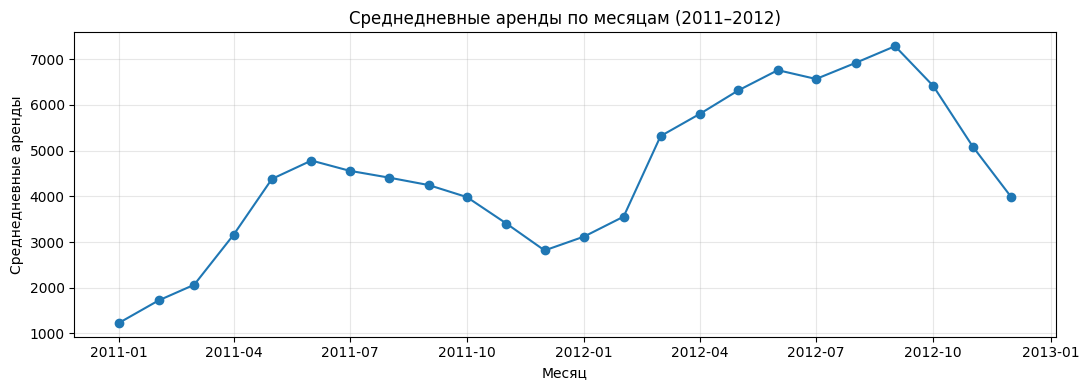

In [4]:
monthly = daily.groupby(["year", "month"])["daily_rentals"].mean().reset_index()
monthly["period"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01"
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly["period"], monthly["daily_rentals"], marker="o")
ax.set_xlabel("Месяц")
ax.set_ylabel("Среднедневные аренды")
ax.set_title("Среднедневные аренды по месяцам (2011–2012)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Наблюдения

- Чёткая сезонность внутри года: летом спрос выше, зимой ниже.
- Уровень 2012 заметно выше 2011 по всему ряду — есть восходящий тренд. Количественно — в §2.

## 2. Рост год к году

---

Считаем рост на обычных днях (без праздников, чтобы не искажать базовый уровень).
Если рост равномерный по месяцам — это органический рост сервиса, а не сезонный артефакт.

In [5]:
year_stats = regular.groupby("year")["daily_rentals"].agg(["mean", "median"]).round(0)
growth_pct = (year_stats.loc[2012, "mean"] / year_stats.loc[2011, "mean"] - 1) * 100

print("Средние аренды по годам (обычные дни):")
print(year_stats)
print(f"\nРост 2012 vs 2011: +{growth_pct:.0f}%")

Средние аренды по годам (обычные дни):
        mean  median
year                
2011  3417.0  3747.0
2012  5637.0  5936.0

Рост 2012 vs 2011: +65%


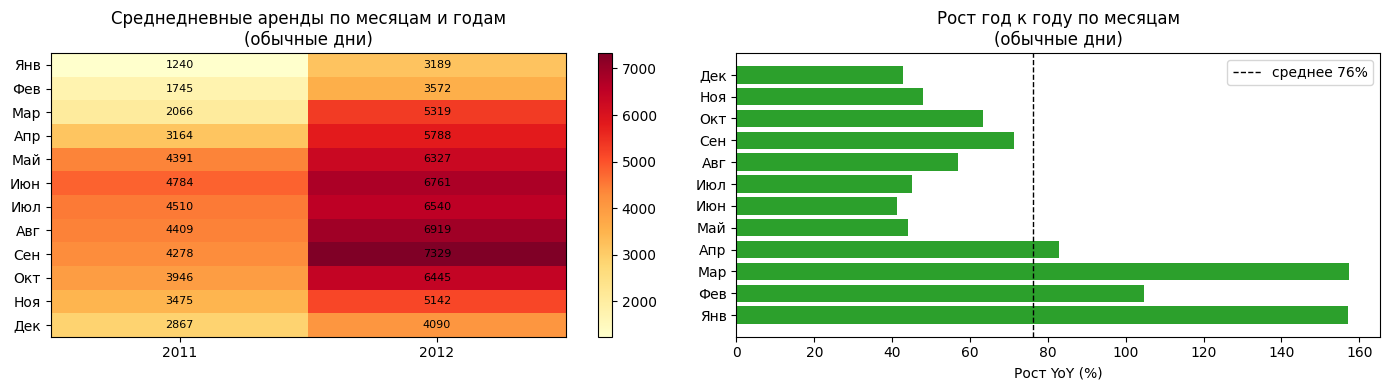

In [6]:
pivot = regular.groupby(["year", "month"])["daily_rentals"].mean().unstack("year").round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(pivot.values, aspect="auto", cmap="YlOrRd")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["2011", "2012"])
axes[0].set_yticks(range(12))
axes[0].set_yticklabels(["Янв", "Фев", "Мар", "Апр", "Май", "Июн",
                          "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"])
for i in range(12):
    for j in range(2):
        axes[0].text(j, i, f"{pivot.values[i, j]:.0f}", ha="center", va="center", fontsize=8)
axes[0].set_title("Среднедневные аренды по месяцам и годам\n(обычные дни)")
plt.colorbar(im, ax=axes[0])

growth = ((pivot[2012] / pivot[2011]) - 1) * 100
axes[1].barh(range(12), growth.values, color="#2ca02c")
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(["Янв", "Фев", "Мар", "Апр", "Май", "Июн",
                          "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"])
axes[1].set_xlabel("Рост YoY (%)")
axes[1].set_title("Рост год к году по месяцам\n(обычные дни)")
axes[1].axvline(growth.mean(), color="black", linestyle="--", linewidth=1,
                label=f"среднее {growth.mean():.0f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

### Наблюдения

- 2012 в среднем на **+65%** выше 2011 на обычных днях.
- Рост положительный **в каждом месяце** без исключений → реальный сдвиг уровня, а не сезонный артефакт. Но он неоднороден (январь +157%, июль +45%): начало 2011 на низкой базе запуска — разделяем в §3.
- Уровень нестабилен во времени: модель без временного признака будет систематически занижать прогноз на 2012.

## 3. Два режима: запуск vs органика

---

Рост +65% неравномерен по месяцам (январь +157%, июль +45%) — это эффект низкой базы:
в начале 2011-го сервис только запускался почти с нуля. Отделим **фазу запуска** от
**органического режима**, чтобы тренд и сезонность не были смешаны с разовой адопцией.

Метод: сезонный индекс (месячное среднее ÷ годовое среднее) для каждого года.
В 2012-м (зрелый весь год) индекс — чистая сезонная форма. Там, где индекс 2011-го
догоняет 2012-й, заканчивается фаза запуска.

In [7]:
# Сезонный индекс = месячное среднее / годовое среднее. В 2012 это чистая сезонность
# (год зрелый целиком). В 2011 ранние месяцы вдобавок придавлены адопцией → индекс ниже.
season_idx = pivot / pivot.mean()
yoy = ((pivot[2012] / pivot[2011]) - 1) * 100

# Граница: пока индекс 2011 ниже 2012 (дефицит адопции) с начала года — это запуск.
boundary = 0
for m in range(1, 13):
    if season_idx.loc[m, 2011] < season_idx.loc[m, 2012]:
        boundary = m
    else:
        break

tbl = pd.DataFrame({
    "индекс_2011": season_idx[2011].round(2),
    "индекс_2012": season_idx[2012].round(2),
    "YoY_%": yoy.round(0),
})
tbl.index = ["Янв", "Фев", "Мар", "Апр", "Май", "Июн",
             "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"]
print(tbl.to_string())
print(f"\nФаза запуска: 2011, месяцы 1..{boundary}. Органический режим: с 2011-{boundary + 1:02d}.")

     индекс_2011  индекс_2012  YoY_%
Янв         0.36         0.57  157.0
Фев         0.51         0.64  105.0
Мар         0.61         0.95  157.0
Апр         0.93         1.03   83.0
Май         1.29         1.13   44.0
Июн         1.40         1.20   41.0
Июл         1.32         1.16   45.0
Авг         1.29         1.23   57.0
Сен         1.26         1.30   71.0
Окт         1.16         1.15   63.0
Ноя         1.02         0.92   48.0
Дек         0.84         0.73   43.0

Фаза запуска: 2011, месяцы 1..4. Органический режим: с 2011-05.


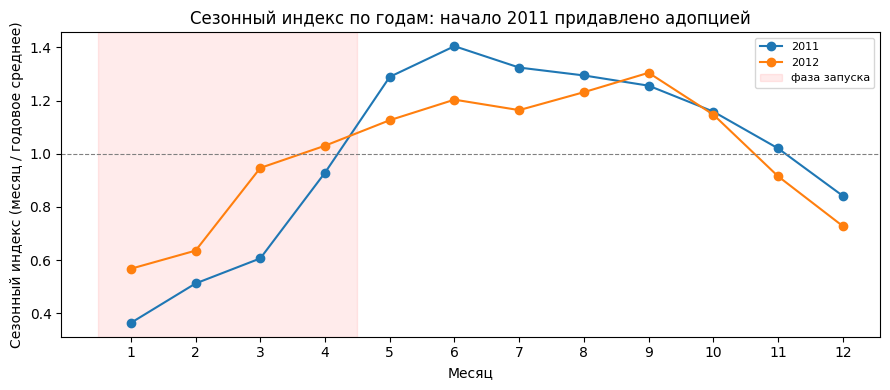

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
months = list(range(1, 13))
ax.plot(months, season_idx[2011], marker="o", label="2011")
ax.plot(months, season_idx[2012], marker="o", label="2012")
ax.axvspan(0.5, boundary + 0.5, color="red", alpha=0.08, label="фаза запуска")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xticks(months)
ax.set_xlabel("Месяц")
ax.set_ylabel("Сезонный индекс (месяц / годовое среднее)")
ax.set_title("Сезонный индекс по годам: начало 2011 придавлено адопцией")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# Рост на органическом режиме: перекрывающиеся зрелые месяцы (после границы) обоих лет.
mature_months = list(range(boundary + 1, 13))
m2011 = pivot.loc[mature_months, 2011].mean()
m2012 = pivot.loc[mature_months, 2012].mean()
mature_growth = (m2012 / m2011 - 1) * 100

print(f"Headline-рост (весь период):                       +{growth_pct:.0f}%")
print(f"Органический рост (мес. {mature_months[0]}–12, оба года зрелые): +{mature_growth:.0f}%")
print("\nРазница = вклад фазы запуска в headline-число.")

Headline-рост (весь период):                       +65%
Органический рост (мес. 5–12, оба года зрелые): +52%

Разница = вклад фазы запуска в headline-число.


### Наблюдения

- **Фаза запуска — примерно январь–апрель 2011, органический режим — с мая 2011** (с этого месяца индекс 2011 года перестаёт быть ниже 2012). Ранние месяцы придавлены не сезоном, а медленным набором аудитории на старте.
- **Поэтому headline +65% завышен запуском.** На зрелых месяцах обоих лет рост скромнее (+52%) — это и есть «настоящий» органический темп.

**Что это меняет:** фаза запуска — разовый эффект, он не повторится. Фичу `days_since_launch` оставляем (дерево уловит перелом), но сами строки запуска — кандидат на удаление из обучения (решим экспериментом). Праздники начала 2011 (MLK, Washington, Emancipation) стоит перепроверить уже на органике (см. [holidays](exploration_holidays.ipynb)).

## 4. День недели и выходные

---

На обычных днях (без праздников): зависит ли спрос от дня недели? Смотрим на двух уровнях — дневной объём и профиль внутри суток.

Искажений здесь почти нет: каждый день недели встречается ~100 раз, равномерно по всему периоду, поэтому рост и сезон в среднем гасятся — можно смотреть сырые средние (в отличие от праздников).

Среднедневные аренды по дню недели (обычные дни):
      mean     std  count
Пн  4399.0  1750.0     90
Вт  4545.0  1803.0    103
Ср  4521.0  2028.0    103
Чт  4720.0  1919.0    102
Пт  4719.0  1882.0    102
Сб  4551.0  2197.0    105
Вс  4229.0  1872.0    105

Будни: 4,585   выходные: 4,390   разница: -4.3%


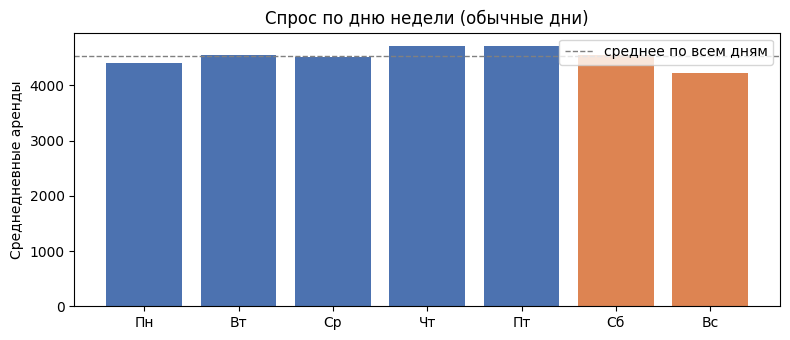

In [10]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

by_dow = regular.groupby("day_of_week")["daily_rentals"].agg(["mean", "std", "count"]).round(0)
by_dow.index = [dow_names[i] for i in by_dow.index]

weekday_mean = regular[regular["day_of_week"] < 5]["daily_rentals"].mean()
weekend_mean = regular[regular["day_of_week"] >= 5]["daily_rentals"].mean()

print("Среднедневные аренды по дню недели (обычные дни):")
print(by_dow.to_string())
print(f"\nБудни: {weekday_mean:,.0f}   выходные: {weekend_mean:,.0f}   "
      f"разница: {(weekend_mean / weekday_mean - 1) * 100:+.1f}%")

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#4c72b0"] * 5 + ["#dd8452"] * 2
ax.bar(by_dow.index, by_dow["mean"], color=colors)
ax.axhline(regular["daily_rentals"].mean(), color="grey", linestyle="--", linewidth=1,
           label="среднее по всем дням")
ax.set_ylabel("Среднедневные аренды"); ax.set_title("Спрос по дню недели (обычные дни)")
ax.legend()
plt.tight_layout(); plt.show()

### Наблюдения

- Дневной объём **почти не зависит от дня недели**: Пн–Вс в диапазоне ~4,230–4,720, будни vs выходные — всего **−4.3%**.
- Как фича *объёма* `is_weekend` слабая — общее число аренд за день примерно одинаковое.
- Но это про суммарный объём. Совпадение объёма не значит совпадение распределения внутри дня → проверяем профиль по часам.

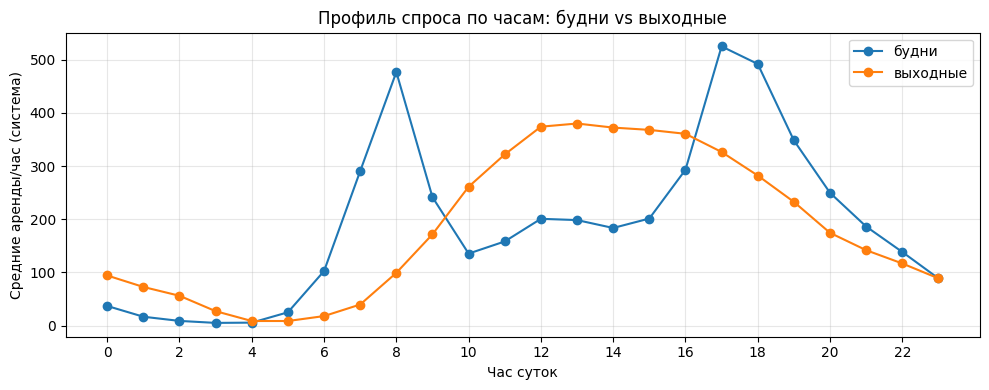

Пиковые часы — будни:    [17, 18, 8]
Пиковые часы — выходные: [13, 12, 14]


In [11]:
# Системный профиль по часам из hourly_by_location (сумма по локациям), обычные дни.
sys_hourly = fd.groupby("datetime_hourly").agg(
    rentals=("total_rentals", "sum"),
    hour=("hour_of_day", "first"),
    is_weekend=("is_weekend", "first"),
    is_holiday=("is_holiday", "max"),
).reset_index()
sys_hourly = sys_hourly[sys_hourly["is_holiday"] == 0]

profile = sys_hourly.groupby(["is_weekend", "hour"])["rentals"].mean().unstack("is_weekend")
profile.columns = ["будни", "выходные"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profile.index, profile["будни"], marker="o", label="будни")
ax.plot(profile.index, profile["выходные"], marker="o", label="выходные")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Час суток"); ax.set_ylabel("Средние аренды/час (система)")
ax.set_title("Профиль спроса по часам: будни vs выходные"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Пиковые часы — будни:   ", profile["будни"].sort_values(ascending=False).head(3).index.tolist())
print("Пиковые часы — выходные:", profile["выходные"].sort_values(ascending=False).head(3).index.tolist())

### Наблюдения

Дневной объём почти одинаковый, но **форма внутри суток разная**:

- **Будни** — два пика, как у поездок на работу: утром в **8:00** и вечером в **17:00–18:00**.
- **Выходные** — один пологий дневной горб в **12:00–14:00** и более активные ночи (0–2ч: ~90 против ~30 в будни — досуг и ночная жизнь).

**Главный вывод:** день недели влияет не на объём, а на **то, когда катаются** — это взаимодействие `is_weekend × hour_of_day`. Сам по себе `is_weekend` меняет дневной объём всего на ~4%, но полностью переставляет суточный профиль.

Для модели: это ровно та структура, которую недооценивал линейный baseline (систематический промах на пиковых часах, см. [eda_and_modeling.ipynb](eda_and_modeling.ipynb)). Линейной модели нужен явный член `час × выходной`; дерево поймает его само.

## Выводы

---

- **Спрос нестабилен во времени:** рост +65% год к году, но он завышен фазой запуска; органический темп — **+52%** (§3).
- **Два режима:** запуск (≈ январь–апрель 2011) и органика (с мая 2011). Запуск — разовый эффект набора аудитории.
- **Фича тренда — `days_since_launch`, а не `year`:** она ловит и сдвиг между годами, и плавный рост внутри 2011 (для линейной это наклон, а не ступенька). За 2013+ модель не экстраполирует (у дерева — «стена»). Строки запуска держим в уме как кандидата на удаление (по эксперименту).
- **Split — хронологический** (оба года и в train, и в test), а не train=2011 / test=2012 — иначе метрики измеряют рост, а не качество паттернов.
- **Для линейной модели:** рост мультипликативный, поэтому стоит рассмотреть лог-таргет.
- **День недели** влияет не на объём (будни vs выходные −4%), а на **форму** суток: будни — пики 8 и 17–18ч, выходные — горб 12–14ч. Польза — во взаимодействии `is_weekend × hour_of_day` (§4).
- **Праздники:** их разброс в основном объясняется ростом сервиса; подробный разбор — в [exploration_holidays.ipynb](exploration_holidays.ipynb).